In [1]:
import cv2
import os
from datetime import timedelta

def create_three_panel_video(top_down_path, eye_cam_path, world_cam_path, output_dir, 
                            start_frame=0, duration_seconds=60, output_filename='three_panel_output.mp4'):
    """
    Creates a three-panel video from three input videos and saves a specified duration clip.
    
    Args:
        top_down_path (str): Path to the top-down view video
        eye_cam_path (str): Path to the eye camera video
        world_cam_path (str): Path to the world camera video
        output_dir (str): Directory to save the output video
        start_frame (int): Frame number to start from (default: 0)
        duration_seconds (int): Duration of clip in seconds (default: 60)
        output_filename (str): Name for the output file (default: 'three_panel_output.mp4')
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    # Open all three video files
    cap_top = cv2.VideoCapture(top_down_path)
    cap_eye = cv2.VideoCapture(eye_cam_path)
    cap_world = cv2.VideoCapture(world_cam_path)
    
    # Check if videos opened successfully
    if not all([cap_top.isOpened(), cap_eye.isOpened(), cap_world.isOpened()]):
        raise ValueError("Could not open one or more video files")
    
    # Get video properties from the first video (we'll match others to this)
    fps = cap_top.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap_top.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap_top.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Calculate total frames to process
    total_frames = int(fps * duration_seconds)
    
    # Set all videos to the starting frame
    cap_top.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    cap_eye.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    cap_world.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    # Create video writer for output (three panels side by side)
    output_width = frame_width * 3
    output_height = frame_height
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (output_width, output_height))
    
    # Process each frame
    for frame_num in range(total_frames):
        ret_top, frame_top = cap_top.read()
        ret_eye, frame_eye = cap_eye.read()
        ret_world, frame_world = cap_world.read()
        
        if not all([ret_top, ret_eye, ret_world]):
            print(f"Warning: Could not read all frames at frame {start_frame + frame_num}")
            break
        
        # Resize all frames to the same dimensions (in case they differ)
        frame_top = cv2.resize(frame_top, (frame_width, frame_height))
        frame_eye = cv2.resize(frame_eye, (frame_width, frame_height))
        frame_world = cv2.resize(frame_world, (frame_width, frame_height))
        
        # Combine frames horizontally
        combined_frame = cv2.hconcat([frame_top, frame_eye, frame_world])
        
        # Add labels to each panel
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(combined_frame, 'Top Down', (10, 30), font, 1, (255, 255, 255), 2)
        cv2.putText(combined_frame, 'Eye Cam', (frame_width + 10, 30), font, 1, (255, 255, 255), 2)
        cv2.putText(combined_frame, 'World Cam', (frame_width*2 + 10, 30), font, 1, (255, 255, 255), 2)
        
        # Write the combined frame
        out.write(combined_frame)
        
        # Print progress
        if frame_num % int(fps) == 0:
            seconds_processed = frame_num / fps
            print(f"Processed {timedelta(seconds=seconds_processed)} of {duration_seconds} seconds")
    
    # Release resources
    cap_top.release()
    cap_eye.release()
    cap_world.release()
    out.release()
    
    print(f"Three-panel video saved to: {output_path}")


# Example usage:
# create_three_panel_video(
#     top_down_path='path/to/top_down.mp4',
#     eye_cam_path='path/to/eye_cam.mp4',
#     world_cam_path='path/to/world_cam.mp4',
#     output_dir='output_directory',
#     start_frame=1200,  # Start at frame 1200
#     duration_seconds=60,
#     output_filename='my_three_panel_video.mp4'
# )

In [1]:
import cv2
import os
from datetime import timedelta

def create_three_panel_video(top_down_path, eye_cam_path, world_cam_path, output_dir, 
                            start_frame=0, duration_seconds=60, output_filename='three_panel_output.mp4'):
    """
    Creates a three-panel video from three input videos and saves a specified duration clip.
    Displays the frame number on each panel of the video.
    
    Args:
        top_down_path (str): Path to the top-down view video
        eye_cam_path (str): Path to the eye camera video
        world_cam_path (str): Path to the world camera video
        output_dir (str): Directory to save the output video
        start_frame (int): Frame number to start from (default: 0)
        duration_seconds (int): Duration of clip in seconds (default: 60)
        output_filename (str): Name for the output file (default: 'three_panel_output.mp4')
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    # Open all three video files
    cap_top = cv2.VideoCapture(top_down_path)
    cap_eye = cv2.VideoCapture(eye_cam_path)
    cap_world = cv2.VideoCapture(world_cam_path)
    
    # Check if videos opened successfully
    if not all([cap_top.isOpened(), cap_eye.isOpened(), cap_world.isOpened()]):
        raise ValueError("Could not open one or more video files")
    
    # Get video properties from the first video (we'll match others to this)
    fps = cap_top.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap_top.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap_top.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Calculate total frames to process
    total_frames = int(fps * duration_seconds)
    
    # Set all videos to the starting frame
    cap_top.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    cap_eye.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    cap_world.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
    # Create video writer for output (three panels side by side)
    output_width = frame_width * 3
    output_height = frame_height
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (output_width, output_height))
    
    # Process each frame
    for frame_num in range(total_frames):
        ret_top, frame_top = cap_top.read()
        ret_eye, frame_eye = cap_eye.read()
        ret_world, frame_world = cap_world.read()
        
        if not all([ret_top, ret_eye, ret_world]):
            print(f"Warning: Could not read all frames at frame {start_frame + frame_num}")
            break
        
        # Resize all frames to the same dimensions (in case they differ)
        frame_top = cv2.resize(frame_top, (frame_width, frame_height))
        frame_eye = cv2.resize(frame_eye, (frame_width, frame_height))
        frame_world = cv2.resize(frame_world, (frame_width, frame_height))
        
        # Get current frame number for each video
        current_frame_top = int(cap_top.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        current_frame_eye = int(cap_eye.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        current_frame_world = int(cap_world.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        
        # Add frame numbers to each frame
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.8
        thickness = 2
        color = (255, 255, 255)  # White text
        bg_color = (0, 0, 0)     # Black background
        
        # Function to add frame number with background for better visibility
        def add_frame_number(frame, frame_num, position):
            text = f"Frame: {frame_num}"
            (text_width, text_height), _ = cv2.getTextSize(text, font, font_scale, thickness)
            
            # Create rectangle background
            cv2.rectangle(frame, 
                         (position[0], position[1] - text_height - 5),
                         (position[0] + text_width + 5, position[1] + 5),
                         bg_color, -1)
            
            # Put text
            cv2.putText(frame, text, (position[0] + 2, position[1] - 5), 
                       font, font_scale, color, thickness)
        
        # Add frame numbers to each panel
        add_frame_number(frame_top, current_frame_top, (10, frame_height - 10))
        add_frame_number(frame_eye, current_frame_eye, (10, frame_height - 10))
        add_frame_number(frame_world, current_frame_world, (10, frame_height - 10))
        
        # Add panel labels at the top
        cv2.putText(frame_top, 'Top Down', (10, 30), font, 1, (255, 255, 255), 2)
        cv2.putText(frame_eye, 'Eye Cam', (10, 30), font, 1, (255, 255, 255), 2)
        cv2.putText(frame_world, 'World Cam', (10, 30), font, 1, (255, 255, 255), 2)
        
        # Combine frames horizontally
        combined_frame = cv2.hconcat([frame_top, frame_eye, frame_world])
        
        # Write the combined frame
        out.write(combined_frame)
        
        # Print progress
        if frame_num % int(fps) == 0:
            seconds_processed = frame_num / fps
            print(f"Processed {timedelta(seconds=seconds_processed)} of {duration_seconds} seconds")
    
    # Release resources
    cap_top.release()
    cap_eye.release()
    cap_world.release()
    out.release()
    
    print(f"Three-panel video saved to: {output_path}")

In [5]:
top_down_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi"
eye_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_eye_plot.avi"
world_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
output_dir=r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'


create_three_panel_video(top_down_path=top_down_path, eye_cam_path=eye_cam_path, world_cam_path=world_cam_path, output_dir=output_dir, 
                            start_frame=3600, duration_seconds=60, output_filename='three_panel_output.mp4')

Processed 0:00:00 of 60 seconds
Processed 0:00:01 of 60 seconds
Processed 0:00:02 of 60 seconds
Processed 0:00:03 of 60 seconds
Processed 0:00:04 of 60 seconds
Processed 0:00:05 of 60 seconds
Processed 0:00:06 of 60 seconds
Processed 0:00:07 of 60 seconds
Processed 0:00:08 of 60 seconds
Processed 0:00:09 of 60 seconds
Processed 0:00:10 of 60 seconds
Processed 0:00:11 of 60 seconds
Processed 0:00:12 of 60 seconds
Processed 0:00:13 of 60 seconds
Processed 0:00:14 of 60 seconds
Processed 0:00:15 of 60 seconds
Processed 0:00:16 of 60 seconds
Processed 0:00:17 of 60 seconds
Processed 0:00:18 of 60 seconds
Processed 0:00:19 of 60 seconds
Processed 0:00:20 of 60 seconds
Processed 0:00:21 of 60 seconds
Processed 0:00:22 of 60 seconds
Processed 0:00:23 of 60 seconds
Processed 0:00:24 of 60 seconds
Processed 0:00:25 of 60 seconds
Processed 0:00:26 of 60 seconds
Processed 0:00:27 of 60 seconds
Processed 0:00:28 of 60 seconds
Processed 0:00:29 of 60 seconds
Processed 0:00:30 of 60 seconds
Processe

In [ ]:
top_down_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi"
eye_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_eye_plot.avi"
world_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
output_dir=r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'


create_three_panel_video(top_down_path=top_down_path, eye_cam_path=eye_cam_path, world_cam_path=world_cam_path, output_dir=output_dir, 
                            start_frame=3600, duration_seconds=60, output_filename='three_panel_output.mp4')

In [7]:
top_down_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi"
eye_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_eye_plot.avi"
world_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
output_dir=r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'


create_three_panel_video(top_down_path=top_down_path, eye_cam_path=eye_cam_path, world_cam_path=world_cam_path, output_dir=output_dir, 
                            start_frame=4020, duration_seconds=10, output_filename='three_panel_output1.mp4')

Processed 0:00:00 of 10 seconds
Processed 0:00:01 of 10 seconds
Processed 0:00:02 of 10 seconds
Processed 0:00:03 of 10 seconds
Processed 0:00:04 of 10 seconds
Processed 0:00:05 of 10 seconds
Processed 0:00:06 of 10 seconds
Processed 0:00:07 of 10 seconds
Processed 0:00:08 of 10 seconds
Processed 0:00:09 of 10 seconds
Three-panel video saved to: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\three_panel_output1.mp4


In [3]:
top_down_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi"
eye_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_eye_plot.avi"
world_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
output_dir=r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'


create_three_panel_video(top_down_path=top_down_path, eye_cam_path=eye_cam_path, world_cam_path=world_cam_path, output_dir=output_dir, 
                            start_frame=3500, duration_seconds=10, output_filename='three_panel_output1.mp4')

Processed 0:00:00 of 10 seconds
Processed 0:00:01 of 10 seconds
Processed 0:00:02 of 10 seconds
Processed 0:00:03 of 10 seconds
Processed 0:00:04 of 10 seconds
Processed 0:00:05 of 10 seconds
Processed 0:00:06 of 10 seconds
Processed 0:00:07 of 10 seconds
Processed 0:00:08 of 10 seconds
Processed 0:00:09 of 10 seconds
Three-panel video saved to: \\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\three_panel_output1.mp4


In [9]:
import cv2
import matplotlib.pyplot as plt
import os

def create_frame_comparison_figure(top_down_video_path, world_cam_video_path, frame_numbers, output_dir, output_filename='frame_comparison'):
    """
    Creates a 2x5 grid figure comparing frames from two videos.
    
    Args:
        top_down_video_path (str): Path to the top-down view video
        world_cam_video_path (str): Path to the world camera video
        frame_numbers (list): List of 5 frame numbers to extract
        output_dir (str): Directory to save the output figure
        output_filename (str): Base name for the output files (without extension)
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Open video files
    cap_top = cv2.VideoCapture(top_down_video_path)
    cap_world = cv2.VideoCapture(world_cam_video_path)
    
    # Check if videos opened successfully
    if not cap_top.isOpened() or not cap_world.isOpened():
        raise ValueError("Could not open one or both video files")
    
    # Verify we have exactly 5 frame numbers
    if len(frame_numbers) != 5:
        raise ValueError("frame_numbers must contain exactly 5 frame numbers")
    
    # Create figure
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    #fig.suptitle('Frame Comparison: Top-Down (Top Row) vs World Camera (Bottom Row)', fontsize=16)
    
    # Extract and display frames
    for i, frame_num in enumerate(frame_numbers):
        # Get top-down frame
        cap_top.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret_top, frame_top = cap_top.read()
        if not ret_top:
            raise ValueError(f"Could not read frame {frame_num} from top-down video")
        
        # Get world camera frame
        cap_world.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret_world, frame_world = cap_world.read()
        if not ret_world:
            raise ValueError(f"Could not read frame {frame_num} from world camera video")
        
        # Convert BGR to RGB for matplotlib
        frame_top_rgb = cv2.cvtColor(frame_top, cv2.COLOR_BGR2RGB)
        frame_world_rgb = cv2.cvtColor(frame_world, cv2.COLOR_BGR2RGB)
        
        # Display frames
        axes[0, i].imshow(frame_top_rgb)
        #axes[0, i].set_title(f'Frame {frame_num}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(frame_world_rgb)
        #axes[1, i].set_title(f'Frame {frame_num}')
        axes[1, i].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figures
    png_path = os.path.join(output_dir, f'{output_filename}.png')
    pdf_path = os.path.join(output_dir, f'{output_filename}.pdf')
    
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.savefig(pdf_path, bbox_inches='tight')
    
    # Close video files
    cap_top.release()
    cap_world.release()
    
    print(f"Figures saved to:\n{png_path}\n{pdf_path}")

# Example usage:
# create_frame_comparison_figure(
#     'path/to/top_down.mp4',
#     'path/to/world_cam.mp4',
#     [100, 200, 300, 400, 500],
#     'output_directory'
# )

Figures saved to:
\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\frame_comparison_051225_F3LILT_no_titile.png
\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\frame_comparison_051225_F3LILT_no_titile.pdf


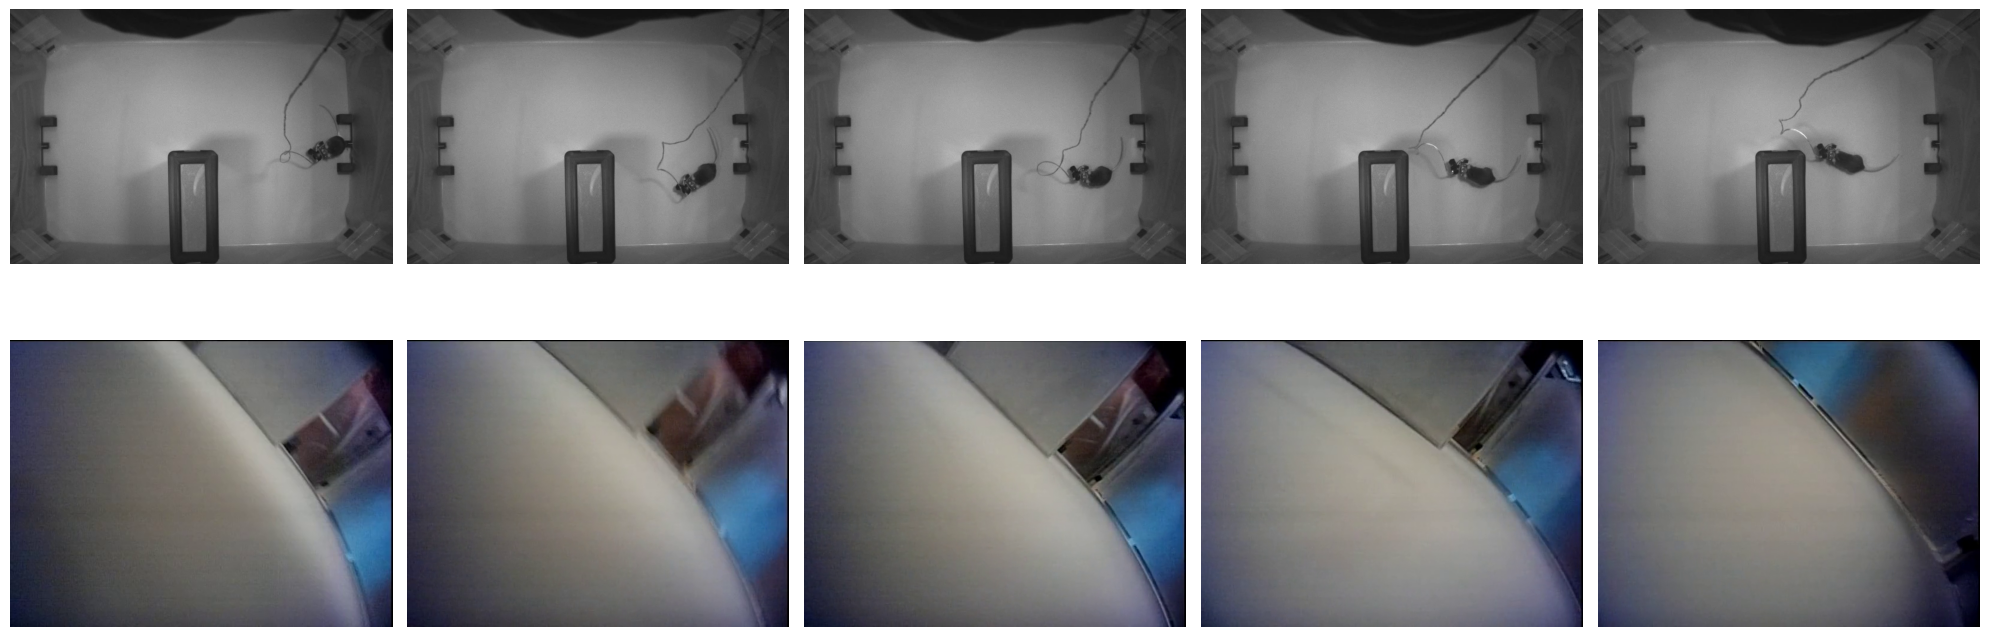

In [10]:
top_down_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_TOP1.avi"
world_cam_path=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
output_dir=r'\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam'

create_frame_comparison_figure(
     top_down_path,
    world_cam_path,
    [3980, 4016, 4022, 4034, 4046],
    output_dir
    , output_filename='frame_comparison_051225_F3LILT_no_titile')